# 05 · Choosing models, comparing families, and XGBoost

`model_name` accepts any classifier or regressor that `sklearn.utils.all_estimators()`
knows, plus `XGBClassifier` and `XGBRegressor`. This tutorial shows how to list them,
how to shortlist a few model families the way chapter 2 recommends, and what the edge
cases look like.

In [1]:
import warnings

warnings.filterwarnings("ignore")  # hide convergence and progress-bar warnings in tutorial output

import optuna

optuna.logging.set_verbosity(optuna.logging.ERROR)  # Optuna otherwise logs every trial, and a traceback per failed one

In [2]:
import matplotlib.pyplot as plt

SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]  # categorical palette, used in this fixed order
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#e5e4e0"


def tidy(ax, title, xlabel, ylabel):
    """Recessive axes and grid so the data, not the frame, carries the chart."""
    ax.set_title(title, loc="left", color=INK, fontsize=12, pad=12)
    ax.set_xlabel(xlabel, color=INK_2)
    ax.set_ylabel(ylabel, color=INK_2)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK_2)
    ax.grid(axis="y", color=GRID, linewidth=1)
    ax.set_axisbelow(True)

## 1. Which names are valid?

In [3]:
from sklearn.utils import all_estimators

classifiers = [name for name, _ in all_estimators(type_filter="classifier")]
regressors = [name for name, _ in all_estimators(type_filter="regressor")]
print(len(classifiers), "classifiers, e.g.", classifiers[:8])
print(len(regressors), "regressors,  e.g.", regressors[:8])

44 classifiers, e.g. ['AdaBoostClassifier', 'BaggingClassifier', 'BernoulliNB', 'CalibratedClassifierCV', 'CategoricalNB', 'ClassifierChain', 'ComplementNB', 'DecisionTreeClassifier']
55 regressors,  e.g. ['ARDRegression', 'AdaBoostRegressor', 'BaggingRegressor', 'BayesianRidge', 'CCA', 'DecisionTreeRegressor', 'DummyRegressor', 'ElasticNet']


Meta-estimators (`StackingClassifier`, `VotingClassifier`, `OneVsRestClassifier`, ...)
are in the list too but need their sub-estimators via `model_kwargs`; see section 5.

## 2. Shortlist several families on the same split

"Try out many other models from various categories ... without spending too much time
tweaking the hyperparameters. The goal is to shortlist a few promising models." Using
one `experiment_name` guarantees every candidate is scored on identical test rows.

In [4]:
from sklearn.datasets import load_breast_cancer

from mloptune import FineTuneConfig, FineTuner

cancer = load_breast_cancer()

candidates = {
    "LogisticRegression": dict(
        search_space={"C": {"type": "float", "low": 1e-3, "high": 1e2, "log": True}},
        model_kwargs={"max_iter": 5000},
    ),
    "KNeighborsClassifier": dict(
        search_space={"n_neighbors": {"type": "int", "low": 1, "high": 25},
                      "weights": {"type": "categorical", "choices": ["uniform", "distance"]}},
    ),
    "RandomForestClassifier": dict(
        search_space={"max_depth": {"type": "int", "low": 2, "high": 12},
                      "max_features": {"type": "categorical", "choices": ["sqrt", "log2", None]}},
        model_kwargs={"n_estimators": 100},
    ),
    "HistGradientBoostingClassifier": dict(
        search_space={"learning_rate": {"type": "float", "low": 0.01, "high": 0.3, "log": True},
                      "max_leaf_nodes": {"type": "int", "low": 4, "high": 32}},
    ),
}

leaderboard = {}
for model_name, extra in candidates.items():
    config = FineTuneConfig(model_name, "classification", "tutorial-05-shortlist", scoring="roc_auc", n_trials=8, **extra)
    leaderboard[model_name] = FineTuner(config).run(cancer.data, cancer.target)
    r = leaderboard[model_name]
    print(f"{model_name:32s} validation={r.validation_score:.4f}  test={r.test_score:.4f}  {r.best_params}")

LogisticRegression               validation=0.9987  test=0.9960  {'C': 9.63967369569964}
KNeighborsClassifier             validation=0.9889  test=0.9610  {'n_neighbors': 13, 'weights': 'distance'}


RandomForestClassifier           validation=0.9921  test=0.9874  {'max_depth': 5, 'max_features': 'sqrt'}


HistGradientBoostingClassifier   validation=0.9987  test=0.9931  {'learning_rate': 0.21782405051483342, 'max_leaf_nodes': 9}


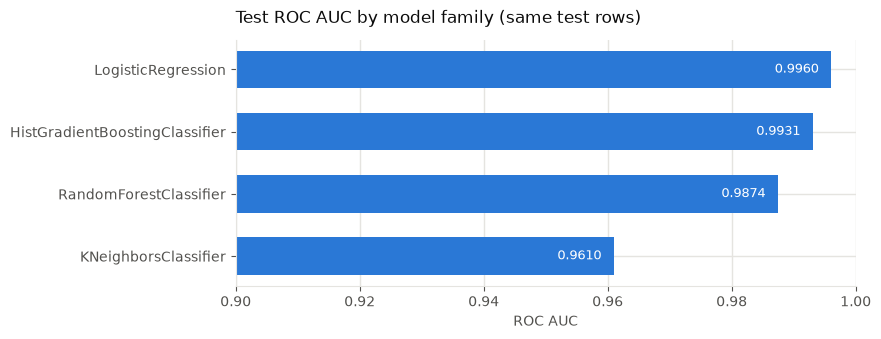

In [5]:
import pandas as pd

scores = pd.Series({k: v.test_score for k, v in leaderboard.items()}).sort_values()

fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.barh(scores.index, scores.values, color=SERIES[0], height=0.6)
for bar, value in zip(bars, scores.values):
    ax.text(value - 0.002, bar.get_y() + bar.get_height() / 2, f"{value:.4f}", va="center", ha="right", color="white", fontsize=9)
ax.set_xlim(0.9, 1.0)
ax.grid(False)
tidy(ax, "Test ROC AUC by model family (same test rows)", "ROC AUC", "")
ax.grid(axis="x", color=GRID, linewidth=1)
plt.show()

Three of the four sit within a hundredth of each other on 114 test rows, which is inside
the noise (tutorial 04 shows how to put an interval on that). `KNeighborsClassifier`
trails because it is distance-based and runs on unscaled features here (see section 7).
Shortlist two or three, not one.

## 3. XGBoost

`XGBClassifier` and `XGBRegressor` are registered when the `xgboost` package can be
imported. On macOS that requires the OpenMP runtime (`brew install libomp`); without it
the aliases are simply absent and everything else works. The experiment seed is passed to
XGBoost as `random_state`, so runs are reproducible.

In [6]:
from mloptune import framework

if framework.XGBClassifier is None:
    print("xgboost is not available here; skipping. Install it (and libomp on macOS) to run this cell.")
else:
    xgb_config = FineTuneConfig(
        model_name="XGBClassifier",
        problem_type="classification",
        experiment_name="tutorial-05-shortlist",
        scoring="roc_auc",
        n_trials=10,
        search_space={
            "n_estimators": {"type": "int", "low": 50, "high": 300, "step": 50},
            "max_depth": {"type": "int", "low": 2, "high": 8},
            "learning_rate": {"type": "float", "low": 0.01, "high": 0.3, "log": True},
            "subsample": {"type": "float", "low": 0.5, "high": 1.0},
            "colsample_bytree": {"type": "float", "low": 0.5, "high": 1.0},
        },
    )
    xgb = FineTuner(xgb_config).run(cancer.data, cancer.target)
    print("best:", xgb.best_params)
    print(f"validation={xgb.validation_score:.4f}  test={xgb.test_score:.4f}")
    print("random_state on the final model:", xgb.model.get_params()["random_state"], "== seed:", xgb.seed)

best: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.11161407695982853, 'subsample': 0.6749078278697009, 'colsample_bytree': 0.7952012864479696}
validation=0.9967  test=0.9931
random_state on the final model: 3736377807 == seed: 3736377807


## 4. The model must match the problem type

Declaring a regressor for classification (or the reverse) used to run silently and
produce nonsense scores. It is now rejected with a message naming the mismatch.

In [7]:
for model_name, problem_type in [("RandomForestRegressor", "classification"), ("LogisticRegression", "regression"), ("KMeans", "classification")]:
    try:
        FineTuner(FineTuneConfig(model_name, problem_type, "tutorial-05-mismatch"))
    except ValueError as exc:
        print(str(exc)[:110])

RandomForestRegressor is a regressor, but problem_type is 'classification'.
LogisticRegression is a classifier, but problem_type is 'regression'.
Unknown model_name: KMeans. It must be a scikit-learn classifier (see sklearn.utils.all_estimators) or an XGBo


## 5. Meta-estimators need their parts via `model_kwargs`

Anything the constructor requires goes in `model_kwargs`. Hyperparameter names are still
validated against the constructor signature.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

stack = FineTuner(
    FineTuneConfig(
        "StackingClassifier", "classification", "tutorial-05-shortlist", scoring="roc_auc",
        model_kwargs={"estimators": [("lr", LogisticRegression(max_iter=5000)), ("dt", DecisionTreeClassifier(max_depth=4))]},
    )
).run(cancer.data, cancer.target)
print(f"StackingClassifier test ROC AUC={stack.test_score:.4f}")

StackingClassifier test ROC AUC=0.9927


## 6. Input containers

NumPy arrays, pandas DataFrames, plain lists and scipy sparse matrices all work, including
for the final refit on train + validation.

In [9]:
import scipy.sparse as sp

as_sparse = FineTuner(
    FineTuneConfig("LogisticRegression", "classification", "tutorial-05-shortlist", model_kwargs={"max_iter": 5000})
).run(sp.csr_matrix(cancer.data), cancer.target)
as_list = FineTuner(
    FineTuneConfig("LogisticRegression", "classification", "tutorial-05-shortlist", model_kwargs={"max_iter": 5000})
).run(cancer.data.tolist(), cancer.target.tolist())
print("sparse test accuracy:", round(as_sparse.test_score, 4), "| list test accuracy:", round(as_list.test_score, 4))

sparse test accuracy: 0.9474 | list test accuracy: 0.9474


## 7. A limitation to know: no preprocessing pipeline

`model_name` refers to a single estimator, so scale-sensitive models (`SVC`,
`KNeighborsClassifier`, `LogisticRegression` with strong regularization) run on raw
features. Scaling the whole `X` beforehand leaks the scaler's statistics from the test
rows into training (chapter 2: "fit the scalers to the training data only"). The leak is
usually small for a standard scaler, but it is a leak.

Prefer tree-based models when features are on wildly different scales, or wait for
pipeline support. The tree ensembles above are unaffected.

## Takeaways

- Any scikit-learn classifier/regressor name works; check `all_estimators(type_filter=...)`.
- Compare families under one `experiment_name` so test rows are shared.
- XGBoost is optional and seeded; meta-estimators take their parts via `model_kwargs`.